4.4.0
cuda


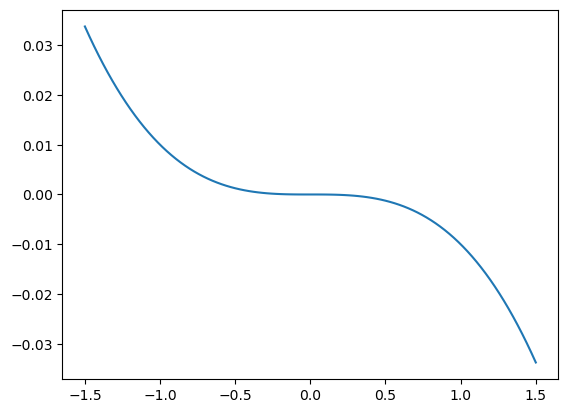

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import optuna

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class NeuralNet(nn.Module):
    
    def __init__(
            self,
            in_features: int,
            out_features: int,
            hidden_dim: int,
            num_layers: int,
            dropout_p: float = 0.2
    ):
        super(NeuralNet, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.dropout_p    = dropout_p

        self.model_layers = self.build_model()
        self.model = nn.Sequential(*self.model_layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        out = self.model(x)

        return out
    
    def build_model(self):
        layer_list = []

        for l in range(self.num_layers):
            # Determine dims for this layer
            if l == 0:
                in_dim, out_dim = self.in_features, self.hidden_dim
            elif l == self.num_layers - 1:
                in_dim, out_dim = self.hidden_dim, self.out_features
            else:
                in_dim = out_dim = self.hidden_dim

            # Linear
            layer_list.append(nn.Linear(in_dim, out_dim))

            # If not final layer, add BN, activation, dropout
            if l < self.num_layers - 1:
                layer_list.append(nn.BatchNorm1d(out_dim))
                layer_list.append(nn.ReLU())
                #layer_list.append(nn.Dropout(self.dropout_p))

        return layer_list

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 9

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
state_dict = torch.load(f="../../SM_1e7_0.pth", map_location=torch.device("cpu"))
model.load_state_dict(state_dict=state_dict)
model.eval()

#print(model)

def target_function(t: torch.Tensor):
    N = t.shape[0]
    t1 = torch.sigmoid(1*t)
    t2 = -0.01*t**3
    return t2

def mse_loss(x: torch.Tensor, y: torch.Tensor):

    N = x.shape[0]
    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse
x = torch.linspace(-1.5, 1.5, 100)
plt.plot(x, target_function(x))

In [2]:
n = 100
min_voltage = -1.5
max_voltage = 1.5
vs = torch.linspace(min_voltage, max_voltage, n)
target = target_function(vs).unsqueeze(1)
#plt.plot(vs, target)
#vs = torch.linspace(-1.5, 1.5, n).unsqueeze(1)
#control_volts = torch.tensor([0.0,  0.2, -0.6, -0.8,  1.5,  1.1]).expand(n, -1)
#print(control_volts)
#input = torch.cat([vs, control_volts], axis=-1)
#print(input)

#currents = model(input).detach().cpu()
#currents_norm = (currents - currents.mean()) / currents.std()

#any_func = target_function(vs)
#any_func_norm = (any_func - any_func.mean()) / any_func.std()

#plt.scatter(vs, currents_norm)
#plt.scatter(vs, any_func_norm)

model.eval()
PRINT_EVERY = 100

def objective(trial):

    cv_list = [trial.suggest_float(f"x_{i}", min_voltage, max_voltage) for i in range(6)]

    cv_tensor = torch.tensor(cv_list, dtype=torch.float32)
    #print(cv_tensor.shape)
    v_input = torch.linspace(min_voltage, max_voltage, n).unsqueeze(1)
    #print(v_input.shape)
    cv_input = cv_tensor.expand(n, -1)
    #print(cv_input.shape)
    input_tensor = torch.cat([v_input, cv_input], dim=-1)
    #print(input_tensor.shape)
    with torch.no_grad():
        y_pred = model(input_tensor).detach().cpu()
    #print(y_pred.shape)

    mse = mse_loss(y_pred, target)
    if trial.number % PRINT_EVERY == 0:
        print('\x1b[6;30;42m' + f'{trial.number}] Finished with score: {mse: .6f}' + '\x1b[0m')

    return mse

tpe = optuna.samplers.TPESampler(multivariate=True, group=True, n_startup_trials=1_000)
study = optuna.create_study(direction="minimize", sampler=tpe)
study.optimize(objective, n_trials=2_000)

/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(


0] Finished with score:  3.564729
100] Finished with score:  3.508497
200] Finished with score:  3.657556
300] Finished with score:  3.564225
400] Finished with score:  3.747255
500] Finished with score:  3.746983
600] Finished with score:  3.563092
700] Finished with score:  3.674596
800] Finished with score:  3.659108
900] Finished with score:  3.767127
1000] Finished with score:  3.495723
1100] Finished with score:  3.414910
1200] Finished with score:  3.432386
1300] Finished with score:  3.634668
1400] Finished with score:  3.509533
1500] Finished with score:  3.688282
1600] Finished with score:  3.432734
1700] Finished with score:  3.518265
1800] Finished with score:  3.497905
1900] Finished with score:  3.450775


tensor([-1.4954, -1.3954, -1.4788,  0.9327, -1.0165,  0.6258])


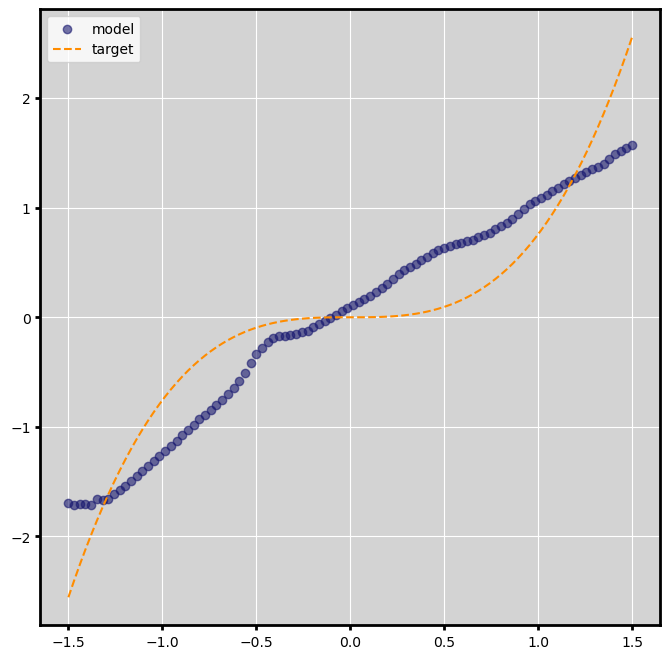

In [54]:
best_trial = study.best_trial
#print(best_trial)
best_volts_list = [best_trial.params[f"x_{i}"] for i in range(6)]
best_volts = torch.tensor(best_volts_list, dtype=torch.float32)
print(best_volts)
best_volts_exp = best_volts.expand(n, -1)

vs = torch.linspace(-1.5, 1.5, n).unsqueeze(1)
inputs = torch.cat([vs, best_volts_exp], dim=-1)

with torch.no_grad():
    best_currents = model(inputs)

best_currents_norm = (best_currents - best_currents.mean()) / best_currents.std()
target_norm = (target - target.mean()) / target.std()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(vs, best_currents_norm, c="midnightblue", alpha=.6, label=f"model", zorder=3)
ax.plot(vs, target_norm, c="darkorange", linestyle="dashed", label=f"target", zorder=3)
ax.legend()

ax.spines[['top', 'bottom', 'right', 'left']].set_linewidth(2.0)
ax.xaxis.set_tick_params(width=2.0)
ax.yaxis.set_tick_params(width=2.0)
ax.set_facecolor("lightgrey")
ax.xaxis.grid(c="w", zorder=1)
ax.yaxis.grid(c="w", zorder=1)